In [16]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage,SystemMessage
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

In [17]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [18]:
llm=ChatOpenAI(
    base_url = "https://integrate.api.nvidia.com/v1",
    model_name="mistralai/mistral-nemotron",
    api_key=os.getenv("NVIDIA_API_KEY")
)

In [19]:
def chat_node(state:ChatState):
    #take user query
    messages=state['messages']



    #send to llm
    response=llm.invoke(messages)


    #response store state
    return {'messages':[response]}

In [20]:
checkpointer=MemorySaver()

graph=StateGraph(ChatState)

#add node
graph.add_node('chat_node',chat_node)

graph.add_edge(START,'chat_node')
graph.add_edge('chat_node',END)


chatbot=graph.compile(checkpointer=checkpointer)


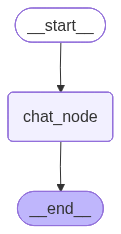

In [21]:
chatbot

In [22]:
initial_state={
    'messages':[HumanMessage(content='what is  the capital of india')]
}

response=chatbot.invoke(initial_state)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
response['messages'][-1].content

"The capital of India is **New Delhi**. It is located in the northern part of the country and serves as the political and administrative center of India. The city is home to important national institutions such as the Parliament, the Rashtrapati Bhavan (President's House), and the Supreme Court.\n\nNew Delhi is also a part of the larger metropolis of **Delhi**, often referred to as the National Capital Territory (NCT) of Delhi.\n\nWould you like more details about the city or its significance?"

In [23]:
thread_id='1'

while True:

    user_message = input("You : ").strip()
    print('User : ',user_message)

    if user_message.strip().lower() in ['exit', 'bye']:
        break

    config={'configurable':{'thread_id':thread_id}}
 
    response = chatbot.invoke({
        'messages': [HumanMessage(content=user_message)]
    })

    print("AI :", response['messages'][-1].content)

User :  hey my name is Pravin


ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id